In [1]:
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
import scipy
from shapely.geometry import LineString, Point
from scipy import ndimage
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
from spectral import *
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1 import make_axes_locatable

def load_plt_setting():
    plt.style.use('seaborn-v0_8-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    plt.rcParams["font.weight"] = "normal"
    plt.rcParams["axes.labelweight"] = "normal"
    plt.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

In [24]:
def calculate_phase_purity_score(
    bandgaps,
    ev_min=1.0,
    ev_max=4.0,
    x_grid=None,
    save_figures=True,
    return_debug=True
):
    """

    Parameters
    ----------
    bandgaps : list of lists
        Output from cal_bandgap(...), where each entry contains the detected
        bandgaps for one pixel.
    ev_min, ev_max : float
        Bandgap search range used to define the KDE grid.
    x_grid : np.ndarray or None
        Optional predefined energy grid. If None, create one internally.
    save_figures : bool
        Whether to generate visualization plots
    return_debug : bool
        Whether to return intermediate quantities for plotting/debugging.

    Returns
    -------
    dict
        Phase purity results with score between 0 and 1.
    """
    import numpy as np
    from scipy.stats import norm, gaussian_kde
    from scipy import integrate
    from scipy.interpolate import interp1d

    # -------- Step 1: Remove invalid pixels and collect valid bandgaps --------
    valid_pixels_data = []
    all_bandgaps = []
    
    for pixel_idx, pixel_bgs in enumerate(bandgaps):
        valid_bgs = [bg for bg in pixel_bgs if bg > 0 and np.isfinite(bg)]
        if len(valid_bgs) > 0:  # Only keep pixels with valid bandgaps
            valid_pixels_data.append(valid_bgs)
            all_bandgaps.extend(valid_bgs)

    n_total_pixels = len(bandgaps)
    n_valid_pixels = len(valid_pixels_data)
    n_invalid_pixels = n_total_pixels - n_valid_pixels
    f_valid = n_valid_pixels / n_total_pixels if n_total_pixels > 0 else 0.0

    print(f"Pixels: {n_total_pixels} total, {n_valid_pixels} valid, {n_invalid_pixels} invalid (f_valid = {f_valid:.3f})")

    if len(all_bandgaps) == 0:
        return {
            "error": "No valid bandgaps found after removing invalid pixels",
            "phase_purity_score": 0.0,  # No valid pixels = zero phase purity
            "dominant_peak": np.nan,
            "peak_fwhm": np.nan,
            "peak_integration": 0.0,
            "f_valid": f_valid,
            "n_total_pixels": n_total_pixels,
            "n_valid_pixels": n_valid_pixels,
            "n_bandgaps": 0,
        }

    all_bandgaps = np.asarray(all_bandgaps, dtype=float)
    
    # -------- Step 2: Set up grid and calculate KDE --------
    if x_grid is None:
        x_min_global = ev_min - 0.2
        x_max_global = ev_max + 0.2
        x_grid = np.linspace(x_min_global, x_max_global, 1000)
    else:
        x_min_global = float(np.min(x_grid))
        x_max_global = float(np.max(x_grid))

    dx = x_grid[1] - x_grid[0]

    # Calculate KDE from valid pixels only
    kde = gaussian_kde(all_bandgaps, bw_method="scott")
    P = kde(x_grid)
    P = np.clip(P, 0, None)
    P /= np.sum(P) * dx  # Normalize to unit area

    P_func = interp1d(x_grid, P, bounds_error=False, fill_value=0.0)
    
    # -------- Step 3: Identify dominant peak (x* = argmax_x P(x)) --------
    peak_idx = np.argmax(P)
    dominant_peak = x_grid[peak_idx]
    peak_height = P[peak_idx]
    
    print(f"Dominant peak found at x* = {dominant_peak:.3f} eV with height = {peak_height:.3f}")
    
    # -------- Step 4: Calculate FWHM and integrate around peak --------
    def calculate_fwhm_and_integrate(x_grid, P, peak_idx, peak_height):
        """Calculate FWHM of the peak and integrate P(x) within FWHM window"""
        half_max = peak_height / 2.0
        
        # Find left and right indices where P crosses half maximum
        # Search left from peak
        left_idx = peak_idx
        while left_idx > 0 and P[left_idx] > half_max:
            left_idx -= 1
        # Linear interpolation for more precise left boundary
        if left_idx < peak_idx and P[left_idx] < half_max:
            alpha = (half_max - P[left_idx]) / (P[left_idx + 1] - P[left_idx])
            x_left = x_grid[left_idx] + alpha * (x_grid[left_idx + 1] - x_grid[left_idx])
        else:
            x_left = x_grid[left_idx]
            
        # Search right from peak  
        right_idx = peak_idx
        while right_idx < len(P) - 1 and P[right_idx] > half_max:
            right_idx += 1
        # Linear interpolation for more precise right boundary
        if right_idx > peak_idx and P[right_idx] < half_max:
            alpha = (half_max - P[right_idx]) / (P[right_idx - 1] - P[right_idx])
            x_right = x_grid[right_idx] + alpha * (x_grid[right_idx - 1] - x_grid[right_idx])
        else:
            x_right = x_grid[right_idx]
        
        fwhm = x_right - x_left
        fwhm_center = (x_left + x_right) / 2.0
        
        # Integrate P(x) within the FWHM window
        mask = (x_grid >= x_left) & (x_grid <= x_right)
        peak_integration = np.sum(P[mask]) * dx
        
        return fwhm, fwhm_center, x_left, x_right, peak_integration
    
    fwhm, fwhm_center, x_left, x_right, peak_integration = calculate_fwhm_and_integrate(
        x_grid, P, peak_idx, peak_height)
    
    print(f"FWHM = {fwhm:.3f} eV, integration window: [{x_left:.3f}, {x_right:.3f}] eV")
    print(f"Peak integration (within FWHM): {peak_integration:.3f}")
    
    # -------- Phase Purity Score = FWHM Integration (already 0-1) --------
    # The FWHM integration of the normalized KDE gives a value between 0 and 1
    # This directly represents the phase purity without need for bad phase penalties
    phase_purity_score = peak_integration
    
    print(f"Phase purity score (FWHM-based): {phase_purity_score:.4f}")
    
    # -------- Visualization --------
    if save_figures:
        load_plt_setting()
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Plot KDE PDF
        ax.plot(x_grid, P, 'b-', linewidth=2, alpha=0.8,
               label=f'KDE Distribution')
        ax.fill_between(x_grid, P, alpha=0.3, color='lightblue')
        
        # Mark dominant peak
        ax.axvline(dominant_peak, color='green', linestyle='-', linewidth=3, alpha=0.8,
                  label=f'Dominant Peak: x*={dominant_peak:.3f} eV')
        ax.plot(dominant_peak, peak_height, 'go', markersize=10)
        
        # Mark FWHM region
        ax.axvspan(x_left, x_right, alpha=0.3, color='green')

        handles, legend_labels = ax.get_legend_handles_labels()
        handles.append(Line2D([], [], linestyle="none"))
        legend_labels.append(f"Phase Purity Proxy: {phase_purity_score:.3f}")
        ax.set_xlabel('Bandgap (eV)', fontsize=32)
        ax.set_ylabel('Probability Density', fontsize=32)
        ax.tick_params(axis='both', direction='out', length=8, width=2, pad=5, labelsize=28)
        ax.tick_params(axis='both', which='minor', direction='out', length=4, width=2, pad=5)
        ax.set_xlim(1.0, 3.0)
        ax.legend(handles=handles,labels=legend_labels,fontsize=22, loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        if savepath:
            plt.savefig(f'{savepath}/film_{film_idx}_phase_purity.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # -------- Return results --------
    results = {
        "phase_purity_score": phase_purity_score,
        "dominant_peak": dominant_peak,
        "peak_height": peak_height, 
        "peak_fwhm": fwhm,
        "fwhm_left": x_left,
        "fwhm_right": x_right,
        "peak_integration": peak_integration,
        "f_valid": f_valid,
        "n_total_pixels": n_total_pixels,
        "n_valid_pixels": n_valid_pixels,
        "n_bandgaps": len(all_bandgaps),
        "bandgap_range": (
            (np.min(all_bandgaps), np.max(all_bandgaps))
            if len(all_bandgaps) > 0 else (np.nan, np.nan)
        ),
        "all_bandgaps": all_bandgaps,
        "valid_pixels_data": valid_pixels_data,
    }

    if return_debug:
        results.update({
            "x_grid": x_grid,
            "P": P,
            "parameters": {
                "ev_min": ev_min,
                "ev_max": ev_max,
            }
        })

    return results


Processing Film 0...
Pixels: 34140 total, 29137 valid, 5003 invalid (f_valid = 0.853)
Dominant peak found at x* = 2.289 eV with height = 7.363
FWHM = 0.067 eV, integration window: [2.256, 2.323] eV
Peak integration (within FWHM): 0.399
Phase purity score (FWHM-based): 0.3991


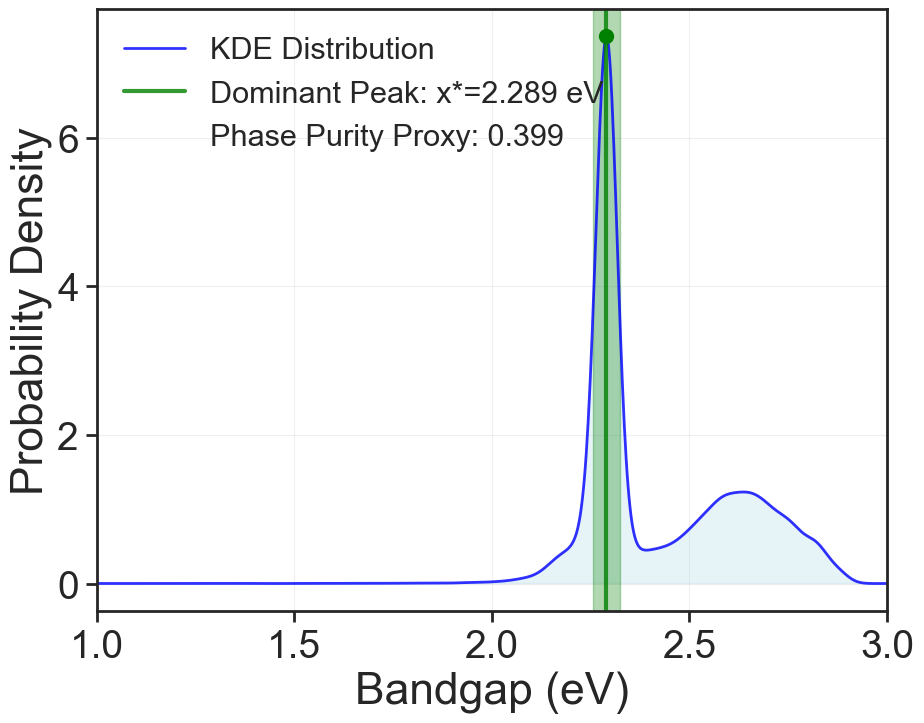

Phase purity score: 0.3991
Dominant peak x*: 2.289 eV
FWHM: 0.067 eV
Bandgaps found: 43181
Valid pixels: 29137/34140

Processing Film 1...
Pixels: 34742 total, 31300 valid, 3442 invalid (f_valid = 0.901)
Dominant peak found at x* = 2.280 eV with height = 8.246
FWHM = 0.064 eV, integration window: [2.247, 2.311] eV
Peak integration (within FWHM): 0.428
Phase purity score (FWHM-based): 0.4282


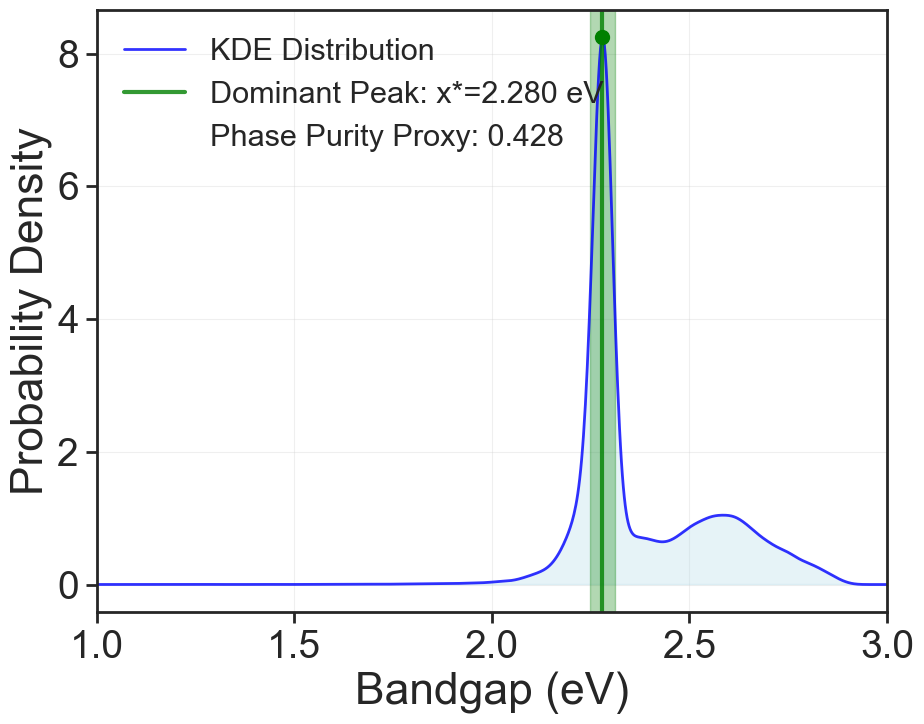

Phase purity score: 0.4282
Dominant peak x*: 2.280 eV
FWHM: 0.064 eV
Bandgaps found: 47048
Valid pixels: 31300/34742

Processing Film 2...
Pixels: 34875 total, 33123 valid, 1752 invalid (f_valid = 0.950)
Dominant peak found at x* = 2.277 eV with height = 10.981
FWHM = 0.055 eV, integration window: [2.249, 2.305] eV
Peak integration (within FWHM): 0.490
Phase purity score (FWHM-based): 0.4900


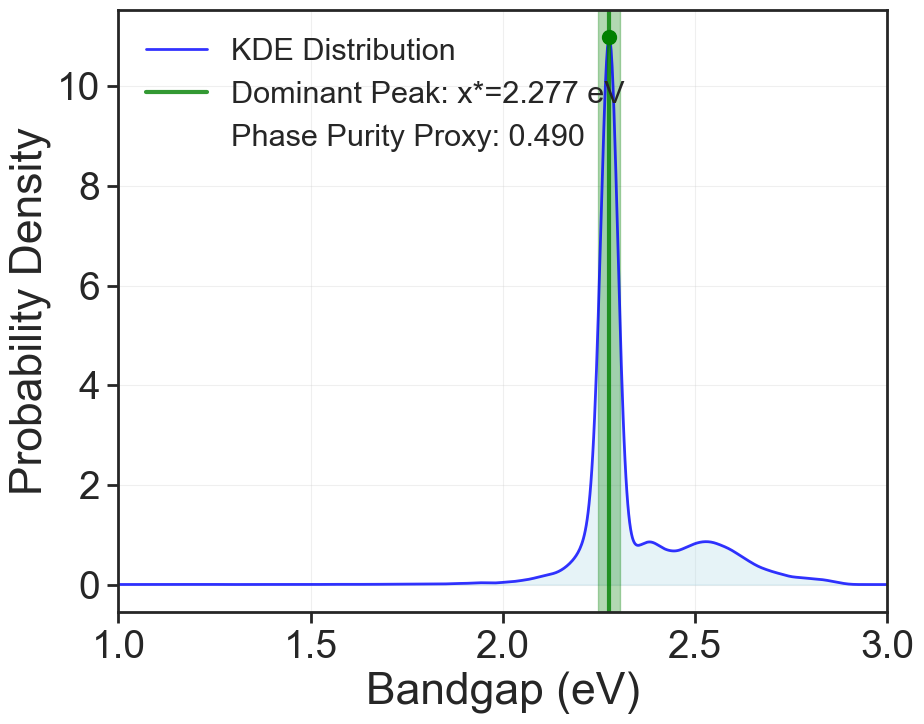

Phase purity score: 0.4900
Dominant peak x*: 2.277 eV
FWHM: 0.055 eV
Bandgaps found: 46466
Valid pixels: 33123/34875

Processing Film 3...
Pixels: 27767 total, 24301 valid, 3466 invalid (f_valid = 0.875)
Dominant peak found at x* = 2.275 eV with height = 5.482
FWHM = 0.093 eV, integration window: [2.222, 2.315] eV
Peak integration (within FWHM): 0.406
Phase purity score (FWHM-based): 0.4055


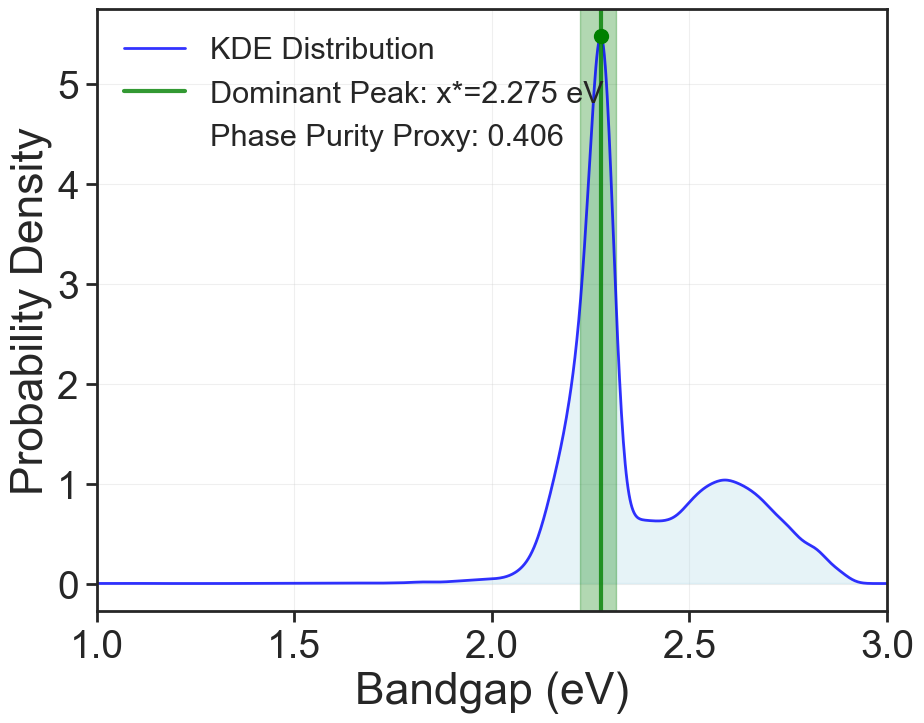

Phase purity score: 0.4055
Dominant peak x*: 2.275 eV
FWHM: 0.093 eV
Bandgaps found: 36886
Valid pixels: 24301/27767

Processing Film 4...
Pixels: 35157 total, 32786 valid, 2371 invalid (f_valid = 0.933)
Dominant peak found at x* = 2.265 eV with height = 8.516
FWHM = 0.065 eV, integration window: [2.231, 2.296] eV
Peak integration (within FWHM): 0.444
Phase purity score (FWHM-based): 0.4445


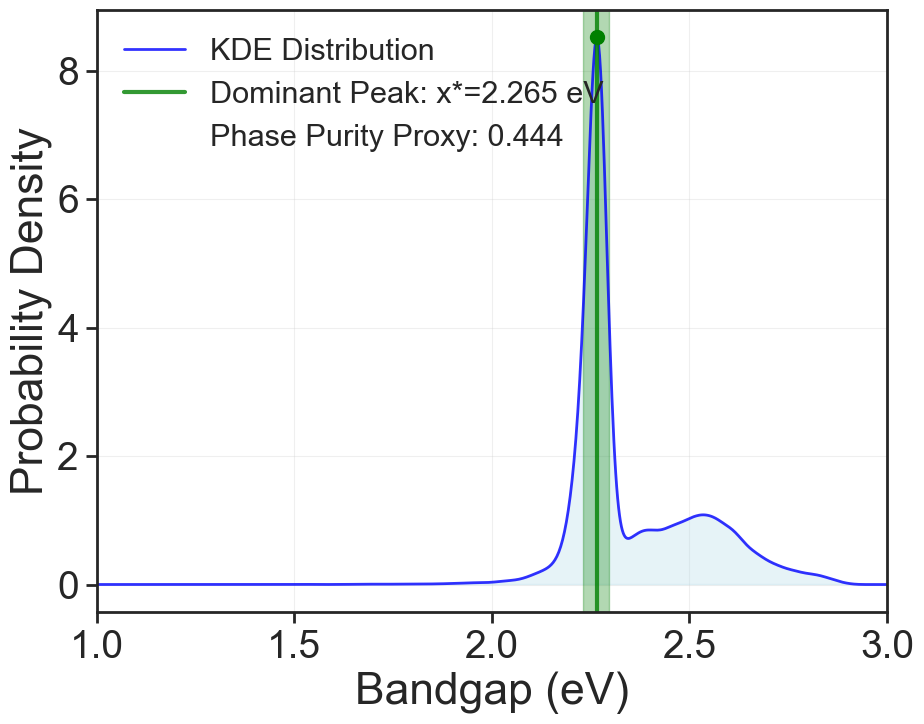

Phase purity score: 0.4445
Dominant peak x*: 2.265 eV
FWHM: 0.065 eV
Bandgaps found: 49964
Valid pixels: 32786/35157

Processing Film 5...
Pixels: 34690 total, 33360 valid, 1330 invalid (f_valid = 0.962)
Dominant peak found at x* = 2.261 eV with height = 10.476
FWHM = 0.054 eV, integration window: [2.232, 2.287] eV
Peak integration (within FWHM): 0.452
Phase purity score (FWHM-based): 0.4515


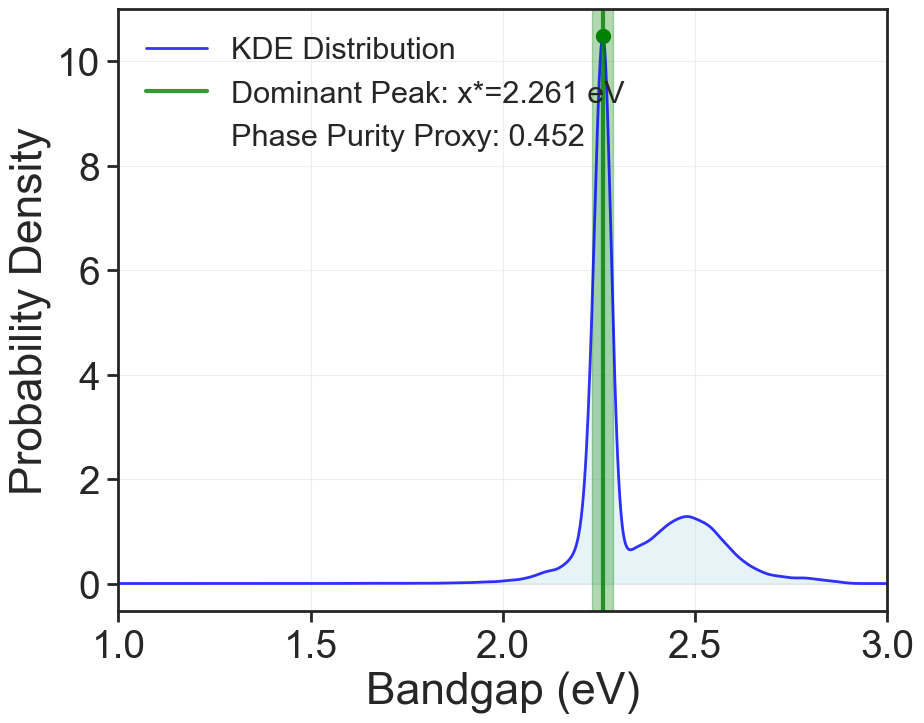

Phase purity score: 0.4515
Dominant peak x*: 2.261 eV
FWHM: 0.054 eV
Bandgaps found: 50812
Valid pixels: 33360/34690

Processing Film 6...
Pixels: 31429 total, 22533 valid, 8896 invalid (f_valid = 0.717)
Dominant peak found at x* = 2.294 eV with height = 2.834
FWHM = 0.124 eV, integration window: [2.232, 2.356] eV
Peak integration (within FWHM): 0.276
Phase purity score (FWHM-based): 0.2765


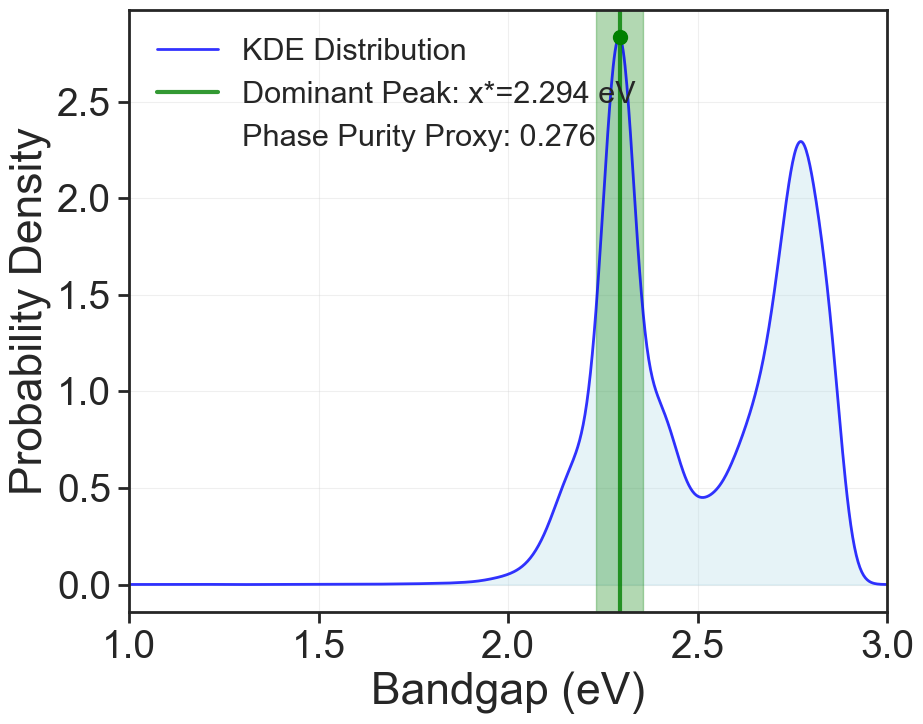

Phase purity score: 0.2765
Dominant peak x*: 2.294 eV
FWHM: 0.124 eV
Bandgaps found: 28326
Valid pixels: 22533/31429

Processing Film 7...
Pixels: 34666 total, 29849 valid, 4817 invalid (f_valid = 0.861)
Dominant peak found at x* = 2.273 eV with height = 7.230
FWHM = 0.074 eV, integration window: [2.235, 2.309] eV
Peak integration (within FWHM): 0.423
Phase purity score (FWHM-based): 0.4234


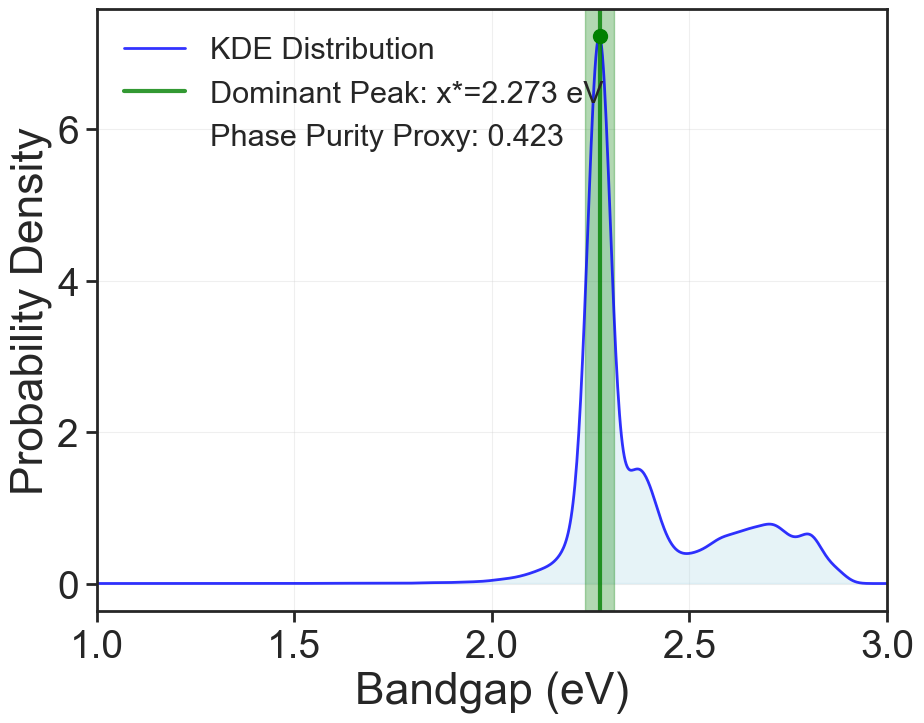

Phase purity score: 0.4234
Dominant peak x*: 2.273 eV
FWHM: 0.074 eV
Bandgaps found: 42280
Valid pixels: 29849/34666

Processing Film 8...
Pixels: 33061 total, 31251 valid, 1810 invalid (f_valid = 0.945)
Dominant peak found at x* = 2.246 eV with height = 11.775
FWHM = 0.050 eV, integration window: [2.220, 2.271] eV
Peak integration (within FWHM): 0.478
Phase purity score (FWHM-based): 0.4784


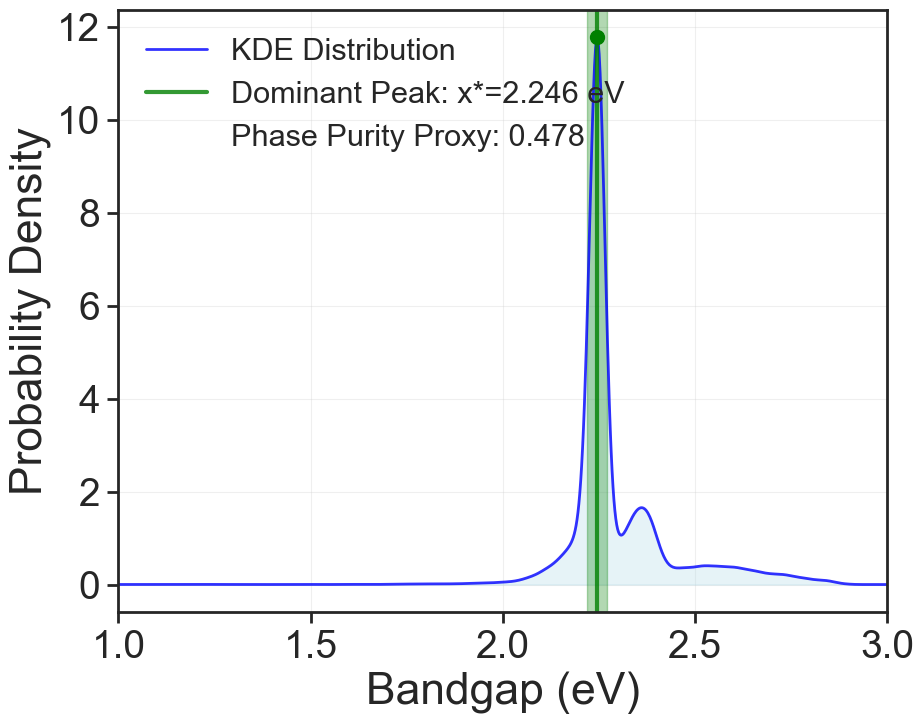

Phase purity score: 0.4784
Dominant peak x*: 2.246 eV
FWHM: 0.050 eV
Bandgaps found: 43197
Valid pixels: 31251/33061

Processing Film 9...
Pixels: 35177 total, 30675 valid, 4502 invalid (f_valid = 0.872)
Dominant peak found at x* = 2.316 eV with height = 6.879
FWHM = 0.070 eV, integration window: [2.280, 2.349] eV
Peak integration (within FWHM): 0.385
Phase purity score (FWHM-based): 0.3854


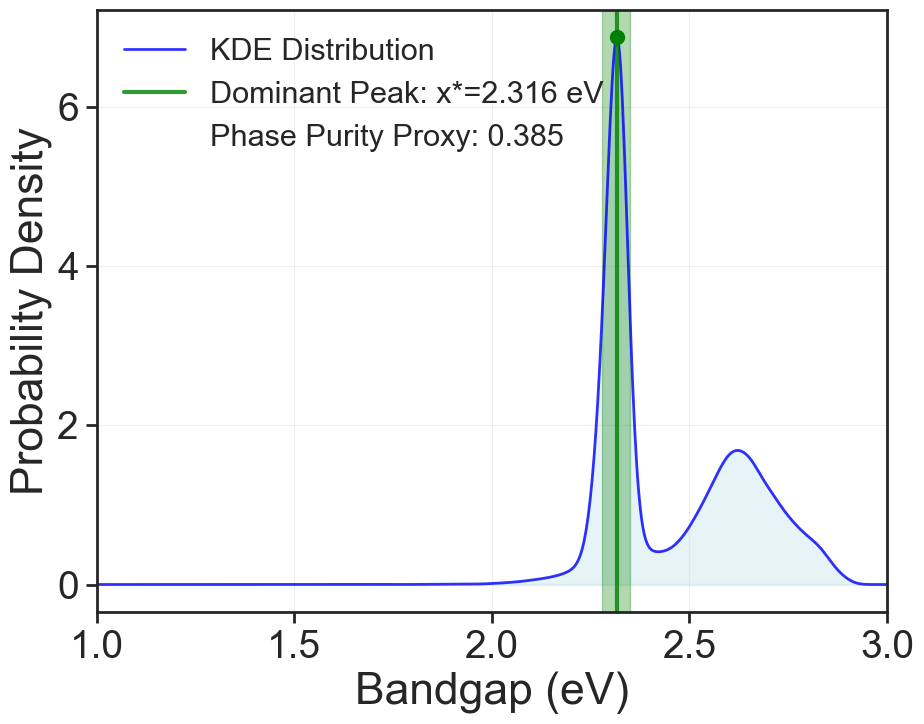

Phase purity score: 0.3854
Dominant peak x*: 2.316 eV
FWHM: 0.070 eV
Bandgaps found: 49556
Valid pixels: 30675/35177

Processing Film 10...
Pixels: 35375 total, 32085 valid, 3290 invalid (f_valid = 0.907)
Dominant peak found at x* = 2.311 eV with height = 7.984
FWHM = 0.061 eV, integration window: [2.281, 2.342] eV
Peak integration (within FWHM): 0.389
Phase purity score (FWHM-based): 0.3887


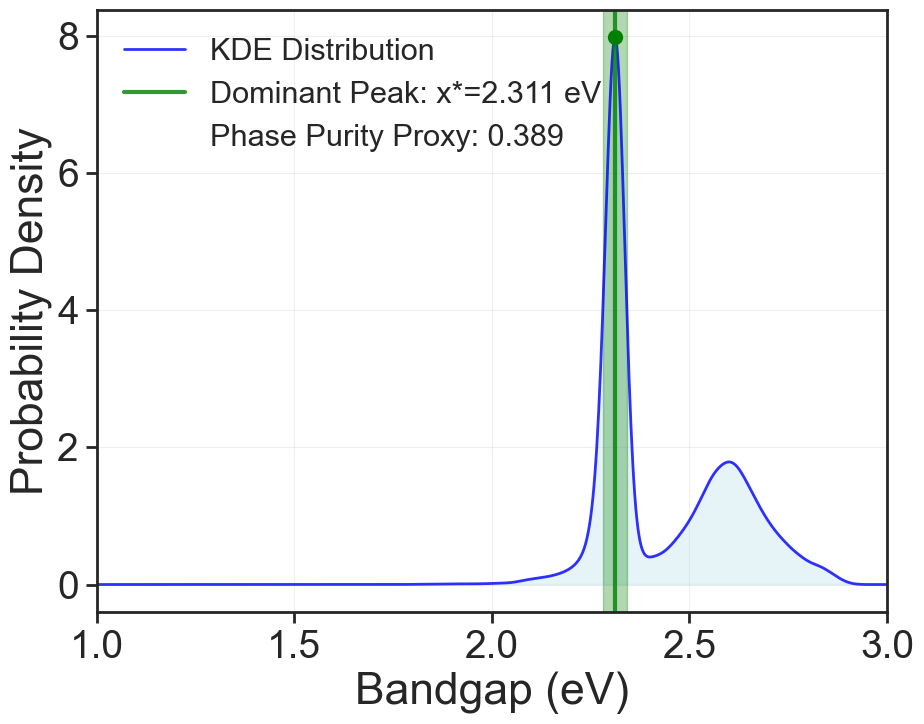

Phase purity score: 0.3887
Dominant peak x*: 2.311 eV
FWHM: 0.061 eV
Bandgaps found: 53199
Valid pixels: 32085/35375

Processing Film 11...
Pixels: 35184 total, 33487 valid, 1697 invalid (f_valid = 0.952)
Dominant peak found at x* = 2.280 eV with height = 8.208
FWHM = 0.058 eV, integration window: [2.250, 2.307] eV
Peak integration (within FWHM): 0.381
Phase purity score (FWHM-based): 0.3808


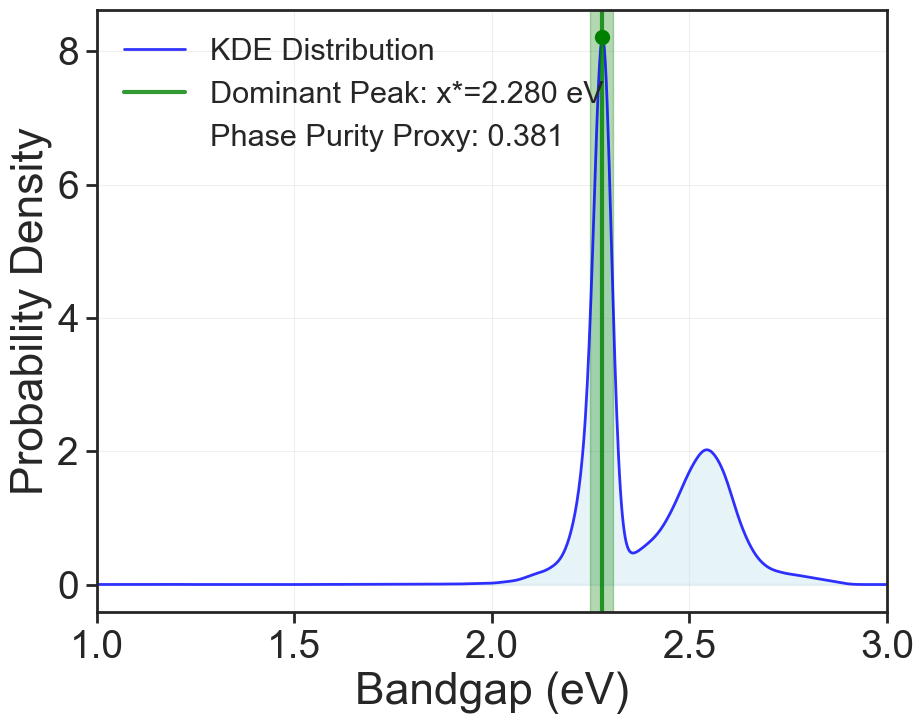

Phase purity score: 0.3808
Dominant peak x*: 2.280 eV
FWHM: 0.058 eV
Bandgaps found: 57725
Valid pixels: 33487/35184

Processing Film 12...
Pixels: 35279 total, 30639 valid, 4640 invalid (f_valid = 0.868)
Dominant peak found at x* = 2.167 eV with height = 6.785
FWHM = 0.075 eV, integration window: [2.132, 2.207] eV
Peak integration (within FWHM): 0.405
Phase purity score (FWHM-based): 0.4055


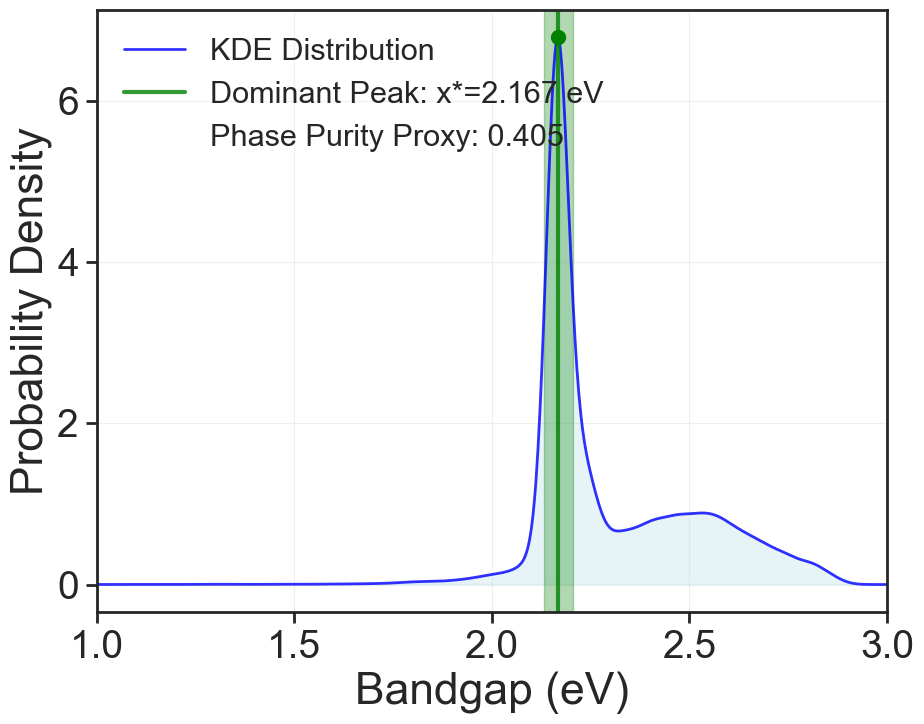

Phase purity score: 0.4055
Dominant peak x*: 2.167 eV
FWHM: 0.075 eV
Bandgaps found: 49698
Valid pixels: 30639/35279

Processing Film 13...
Pixels: 35172 total, 31344 valid, 3828 invalid (f_valid = 0.891)
Dominant peak found at x* = 2.191 eV with height = 4.517
FWHM = 0.136 eV, integration window: [2.145, 2.280] eV
Peak integration (within FWHM): 0.500
Phase purity score (FWHM-based): 0.4999


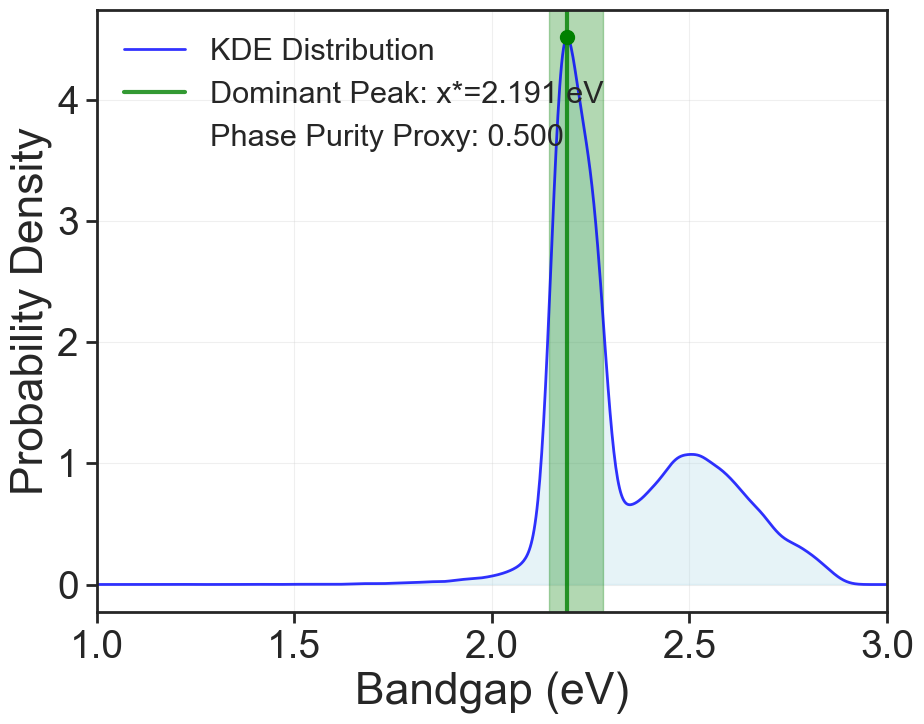

Phase purity score: 0.4999
Dominant peak x*: 2.191 eV
FWHM: 0.136 eV
Bandgaps found: 51260
Valid pixels: 31344/35172

Processing Film 14...
Pixels: 35279 total, 32121 valid, 3158 invalid (f_valid = 0.910)
Dominant peak found at x* = 2.208 eV with height = 4.277
FWHM = 0.147 eV, integration window: [2.143, 2.290] eV
Peak integration (within FWHM): 0.535
Phase purity score (FWHM-based): 0.5348


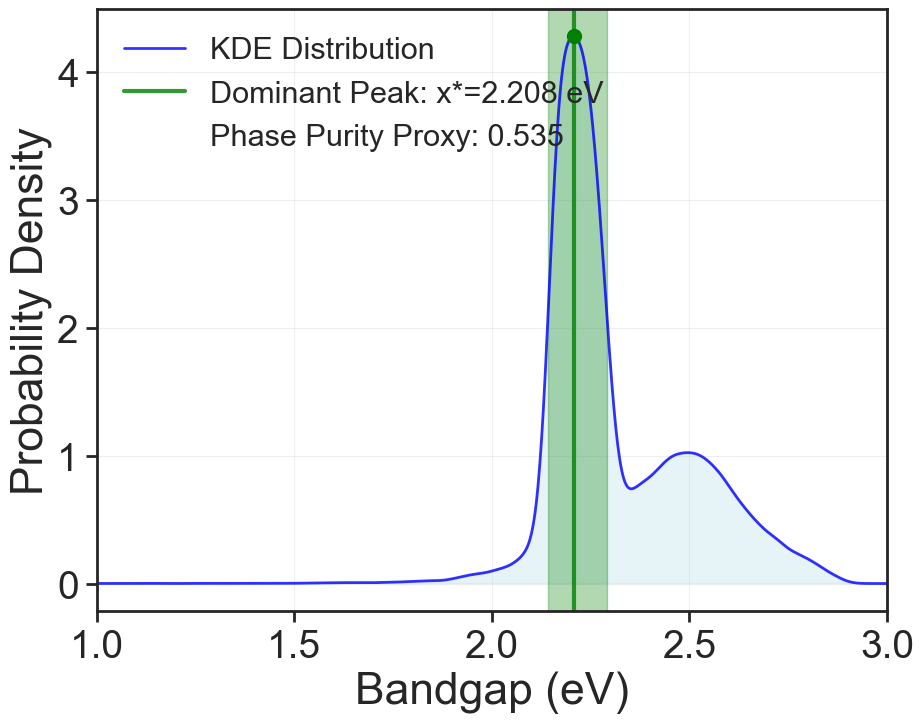

Phase purity score: 0.5348
Dominant peak x*: 2.208 eV
FWHM: 0.147 eV
Bandgaps found: 51636
Valid pixels: 32121/35279

Processing Film 15...
Pixels: 33526 total, 28279 valid, 5247 invalid (f_valid = 0.843)
Dominant peak found at x* = 2.150 eV with height = 4.641
FWHM = 0.124 eV, integration window: [2.092, 2.216] eV
Peak integration (within FWHM): 0.469
Phase purity score (FWHM-based): 0.4687


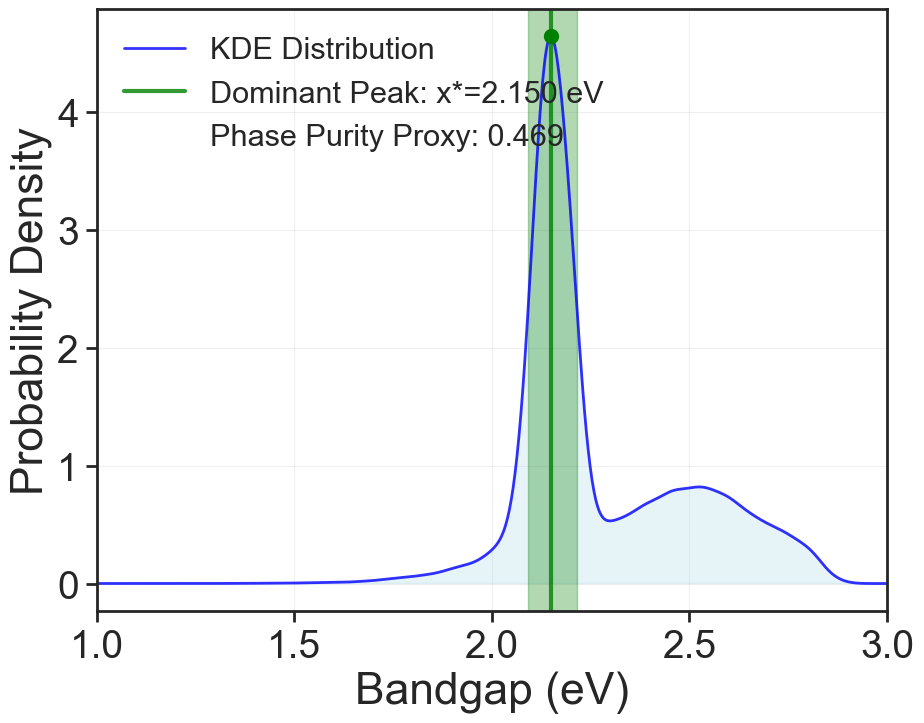

Phase purity score: 0.4687
Dominant peak x*: 2.150 eV
FWHM: 0.124 eV
Bandgaps found: 47401
Valid pixels: 28279/33526

Processing Film 16...
Pixels: 26283 total, 23741 valid, 2542 invalid (f_valid = 0.903)
Dominant peak found at x* = 2.145 eV with height = 5.394
FWHM = 0.107 eV, integration window: [2.093, 2.200] eV
Peak integration (within FWHM): 0.465
Phase purity score (FWHM-based): 0.4648


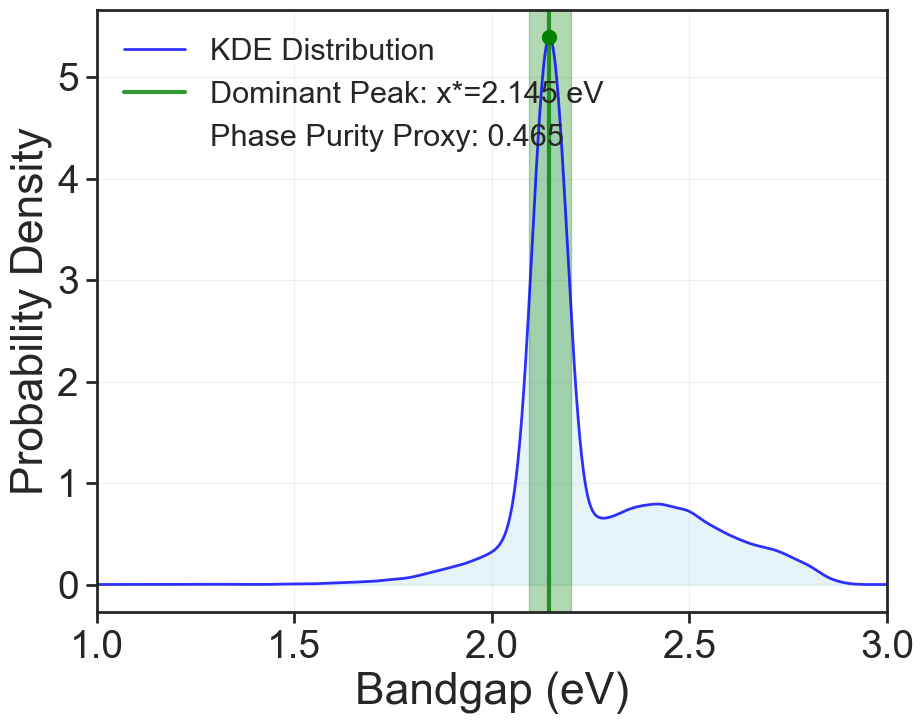

Phase purity score: 0.4648
Dominant peak x*: 2.145 eV
FWHM: 0.107 eV
Bandgaps found: 39787
Valid pixels: 23741/26283

Processing Film 17...
Pixels: 19294 total, 16907 valid, 2387 invalid (f_valid = 0.876)
Dominant peak found at x* = 2.136 eV with height = 5.407
FWHM = 0.104 eV, integration window: [2.082, 2.186] eV
Peak integration (within FWHM): 0.450
Phase purity score (FWHM-based): 0.4501


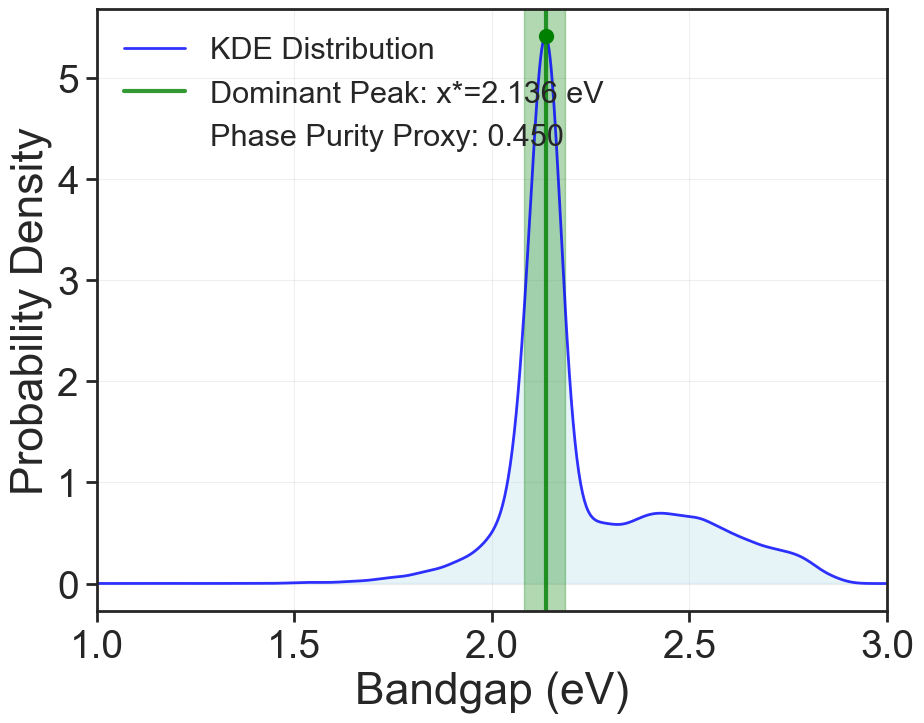

Phase purity score: 0.4501
Dominant peak x*: 2.136 eV
FWHM: 0.104 eV
Bandgaps found: 28538
Valid pixels: 16907/19294

Processing Film 18...
Pixels: 37089 total, 31560 valid, 5529 invalid (f_valid = 0.851)
Dominant peak found at x* = 2.270 eV with height = 6.718
FWHM = 0.071 eV, integration window: [2.234, 2.305] eV
Peak integration (within FWHM): 0.387
Phase purity score (FWHM-based): 0.3871


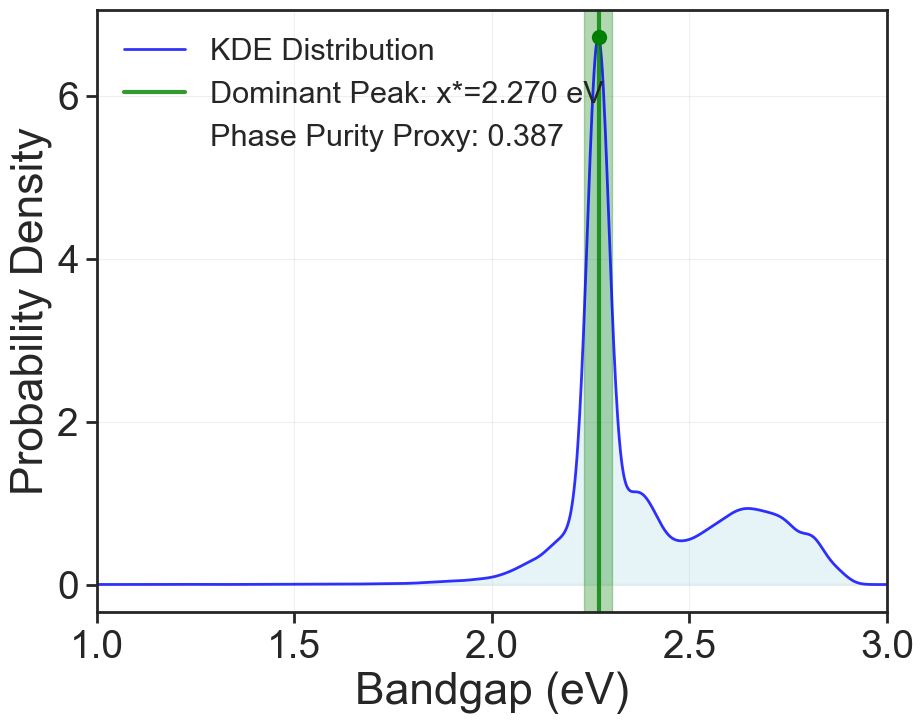

Phase purity score: 0.3871
Dominant peak x*: 2.270 eV
FWHM: 0.071 eV
Bandgaps found: 45615
Valid pixels: 31560/37089

Processing Film 19...
Pixels: 36687 total, 32796 valid, 3891 invalid (f_valid = 0.894)
Dominant peak found at x* = 2.261 eV with height = 7.419
FWHM = 0.068 eV, integration window: [2.226, 2.295] eV
Peak integration (within FWHM): 0.412
Phase purity score (FWHM-based): 0.4121


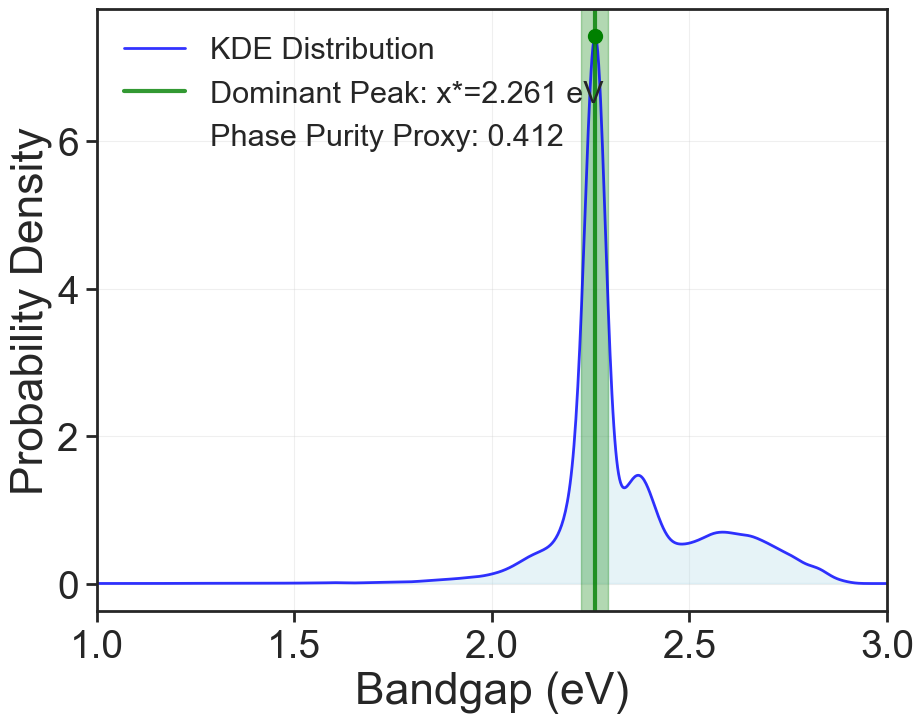

Phase purity score: 0.4121
Dominant peak x*: 2.261 eV
FWHM: 0.068 eV
Bandgaps found: 48873
Valid pixels: 32796/36687

Processing Film 20...
Pixels: 37027 total, 35213 valid, 1814 invalid (f_valid = 0.951)
Dominant peak found at x* = 2.241 eV with height = 10.317
FWHM = 0.056 eV, integration window: [2.213, 2.270] eV
Peak integration (within FWHM): 0.463
Phase purity score (FWHM-based): 0.4625


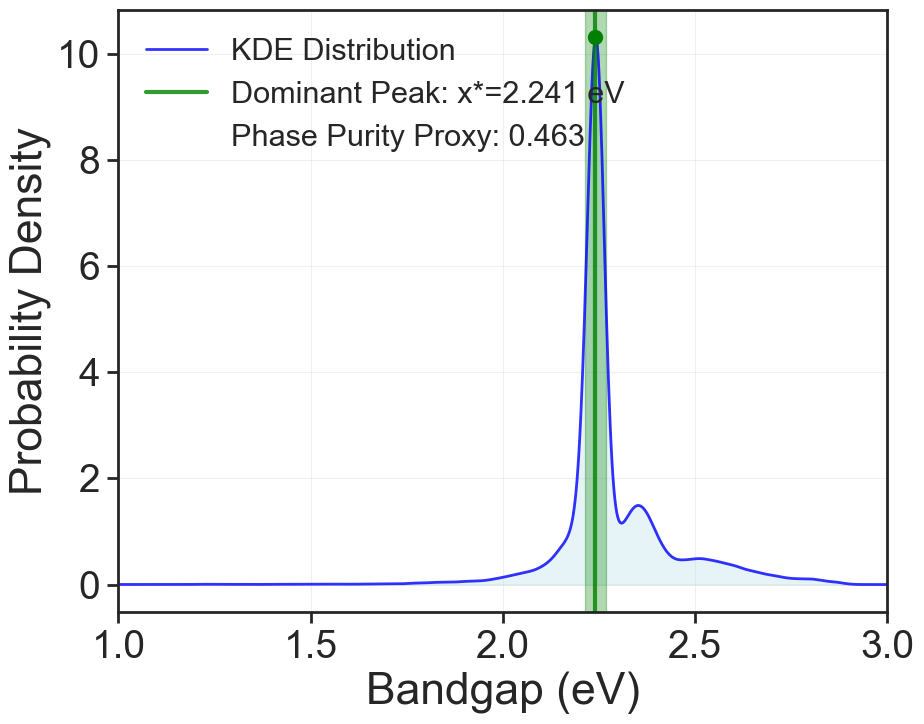

Phase purity score: 0.4625
Dominant peak x*: 2.241 eV
FWHM: 0.056 eV
Bandgaps found: 49943
Valid pixels: 35213/37027

Processing Film 21...
Pixels: 36512 total, 32315 valid, 4197 invalid (f_valid = 0.885)
Dominant peak found at x* = 2.419 eV with height = 3.060
FWHM = 0.257 eV, integration window: [2.336, 2.593] eV
Peak integration (within FWHM): 0.616
Phase purity score (FWHM-based): 0.6159


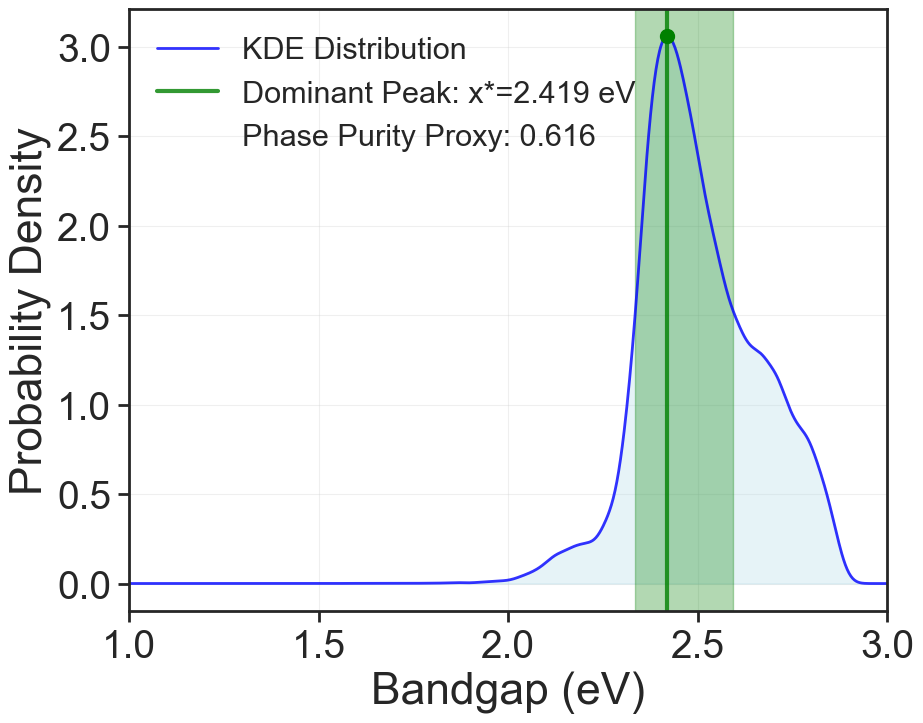

Phase purity score: 0.6159
Dominant peak x*: 2.419 eV
FWHM: 0.257 eV
Bandgaps found: 38564
Valid pixels: 32315/36512

Processing Film 22...
Pixels: 23411 total, 21293 valid, 2118 invalid (f_valid = 0.910)
Dominant peak found at x* = 2.453 eV with height = 3.154
FWHM = 0.241 eV, integration window: [2.343, 2.583] eV
Peak integration (within FWHM): 0.608
Phase purity score (FWHM-based): 0.6084


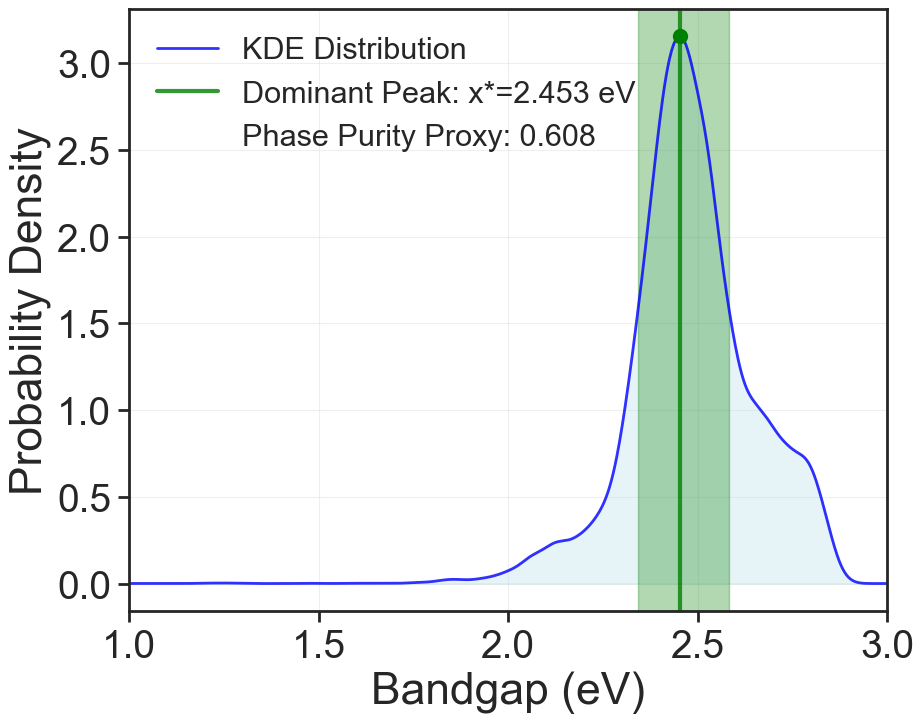

Phase purity score: 0.6084
Dominant peak x*: 2.453 eV
FWHM: 0.241 eV
Bandgaps found: 24895
Valid pixels: 21293/23411

Processing Film 23...
Pixels: 4042 total, 3378 valid, 664 invalid (f_valid = 0.836)
Dominant peak found at x* = 2.150 eV with height = 1.741
FWHM = 0.593 eV, integration window: [2.038, 2.632] eV
Peak integration (within FWHM): 0.747
Phase purity score (FWHM-based): 0.7471


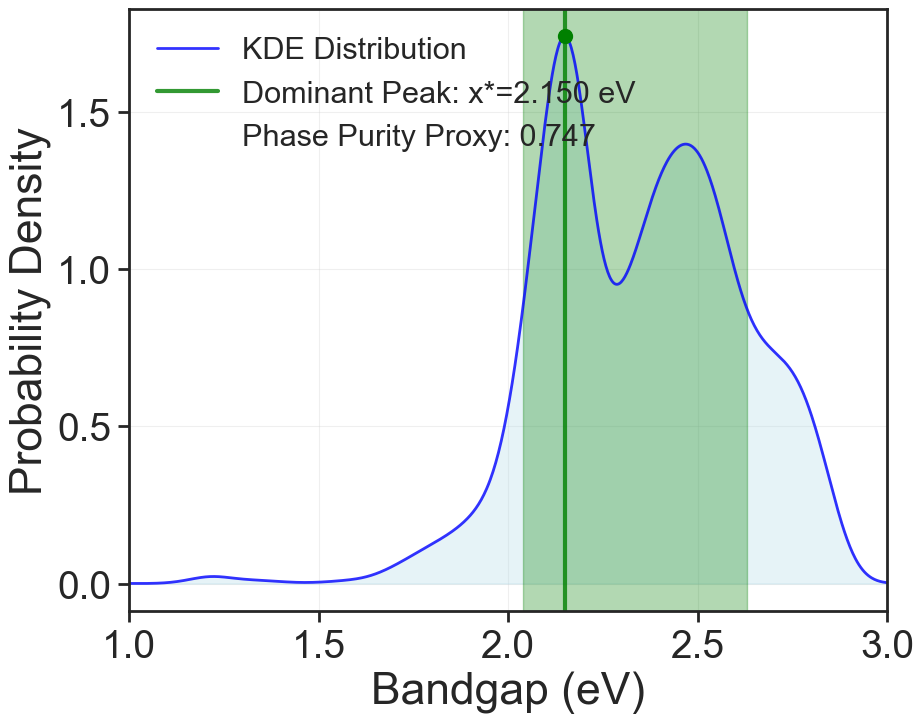

Phase purity score: 0.7471
Dominant peak x*: 2.150 eV
FWHM: 0.593 eV
Bandgaps found: 4499
Valid pixels: 3378/4042

Processing Film 24...
Pixels: 37121 total, 27249 valid, 9872 invalid (f_valid = 0.734)
Dominant peak found at x* = 2.268 eV with height = 2.821
FWHM = 0.221 eV, integration window: [2.210, 2.432] eV
Peak integration (within FWHM): 0.427
Phase purity score (FWHM-based): 0.4269


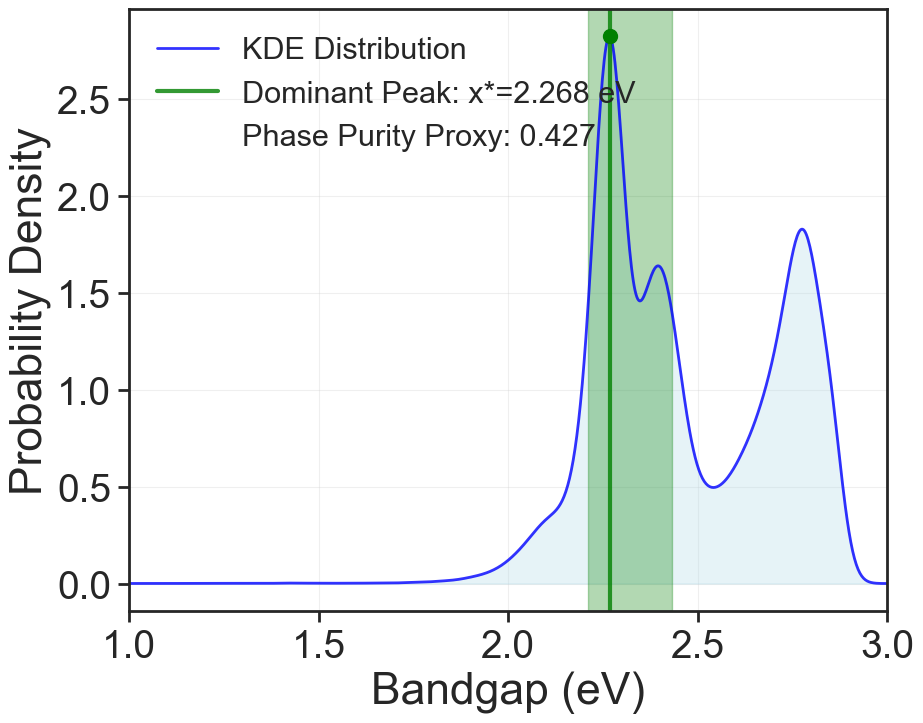

Phase purity score: 0.4269
Dominant peak x*: 2.268 eV
FWHM: 0.221 eV
Bandgaps found: 36785
Valid pixels: 27249/37121

Processing Film 25...
Pixels: 37248 total, 33157 valid, 4091 invalid (f_valid = 0.890)
Dominant peak found at x* = 2.237 eV with height = 6.822
FWHM = 0.060 eV, integration window: [2.206, 2.266] eV
Peak integration (within FWHM): 0.329
Phase purity score (FWHM-based): 0.3293


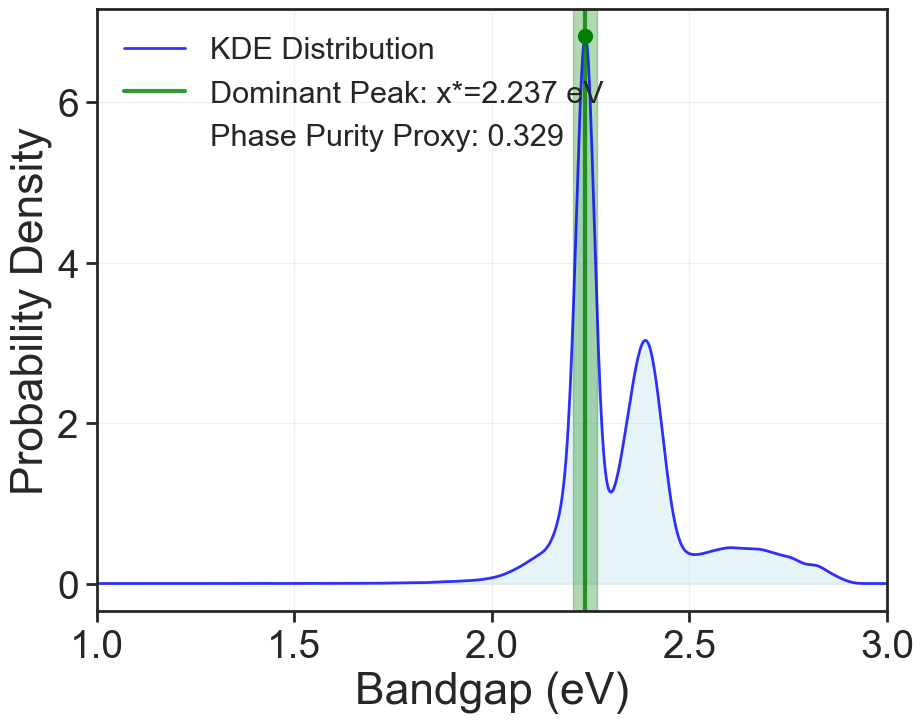

Phase purity score: 0.3293
Dominant peak x*: 2.237 eV
FWHM: 0.060 eV
Bandgaps found: 55664
Valid pixels: 33157/37248

Processing Film 26...
Pixels: 37195 total, 34571 valid, 2624 invalid (f_valid = 0.929)
Dominant peak found at x* = 2.237 eV with height = 9.383
FWHM = 0.051 eV, integration window: [2.211, 2.262] eV
Peak integration (within FWHM): 0.382
Phase purity score (FWHM-based): 0.3821


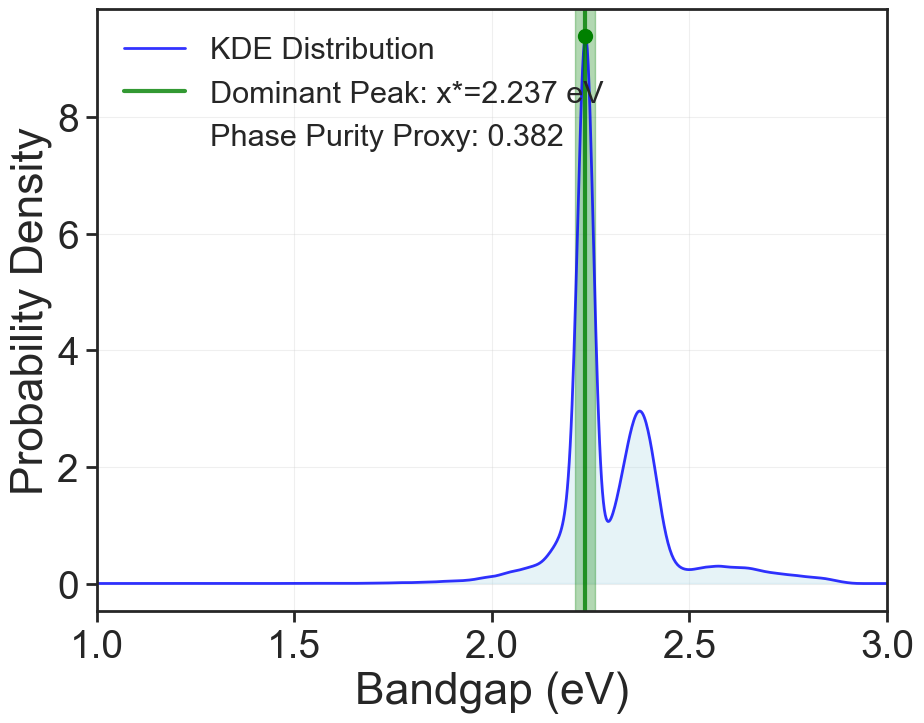

Phase purity score: 0.3821
Dominant peak x*: 2.237 eV
FWHM: 0.051 eV
Bandgaps found: 56159
Valid pixels: 34571/37195

Processing Film 27...
Pixels: 36645 total, 33620 valid, 3025 invalid (f_valid = 0.917)
Dominant peak found at x* = 2.374 eV with height = 4.161
FWHM = 0.165 eV, integration window: [2.306, 2.471] eV
Peak integration (within FWHM): 0.544
Phase purity score (FWHM-based): 0.5438


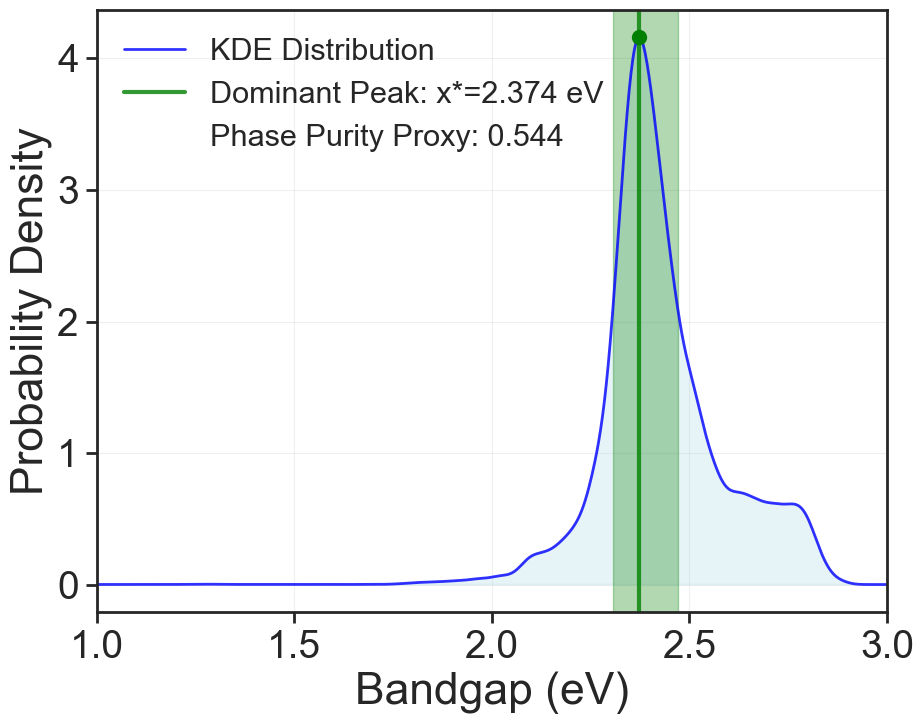

Phase purity score: 0.5438
Dominant peak x*: 2.374 eV
FWHM: 0.165 eV
Bandgaps found: 39838
Valid pixels: 33620/36645

Processing Film 28...
Pixels: 36493 total, 32692 valid, 3801 invalid (f_valid = 0.896)
Dominant peak found at x* = 2.407 eV with height = 2.439
FWHM = 0.386 eV, integration window: [2.161, 2.547] eV
Peak integration (within FWHM): 0.728
Phase purity score (FWHM-based): 0.7277


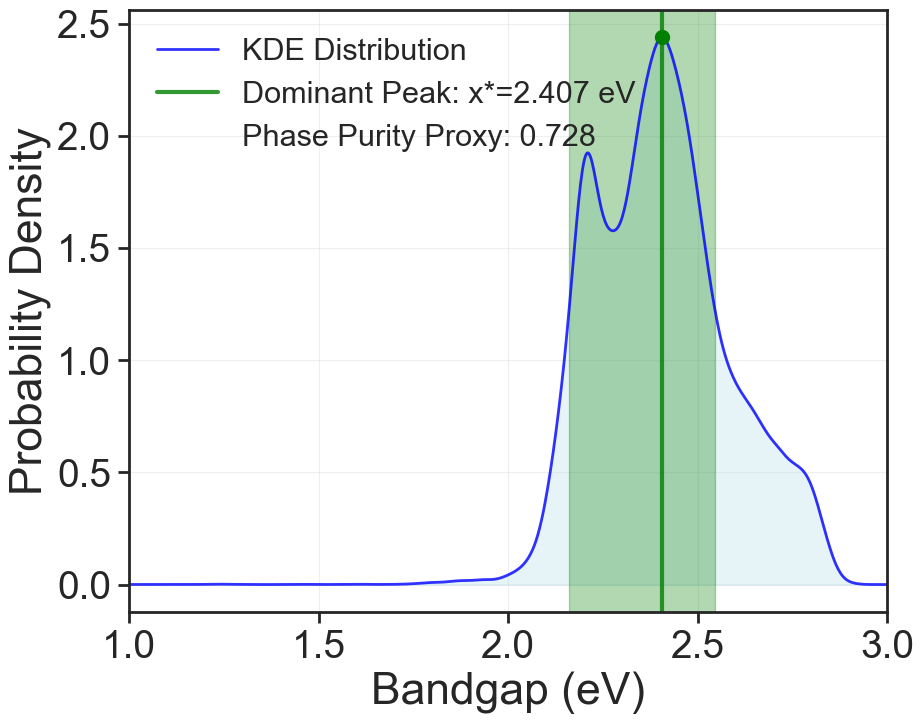

Phase purity score: 0.7277
Dominant peak x*: 2.407 eV
FWHM: 0.386 eV
Bandgaps found: 43953
Valid pixels: 32692/36493

Processing Film 29...
Pixels: 36606 total, 30788 valid, 5818 invalid (f_valid = 0.841)
Dominant peak found at x* = 2.172 eV with height = 4.814
FWHM = 0.098 eV, integration window: [2.120, 2.218] eV
Peak integration (within FWHM): 0.379
Phase purity score (FWHM-based): 0.3793


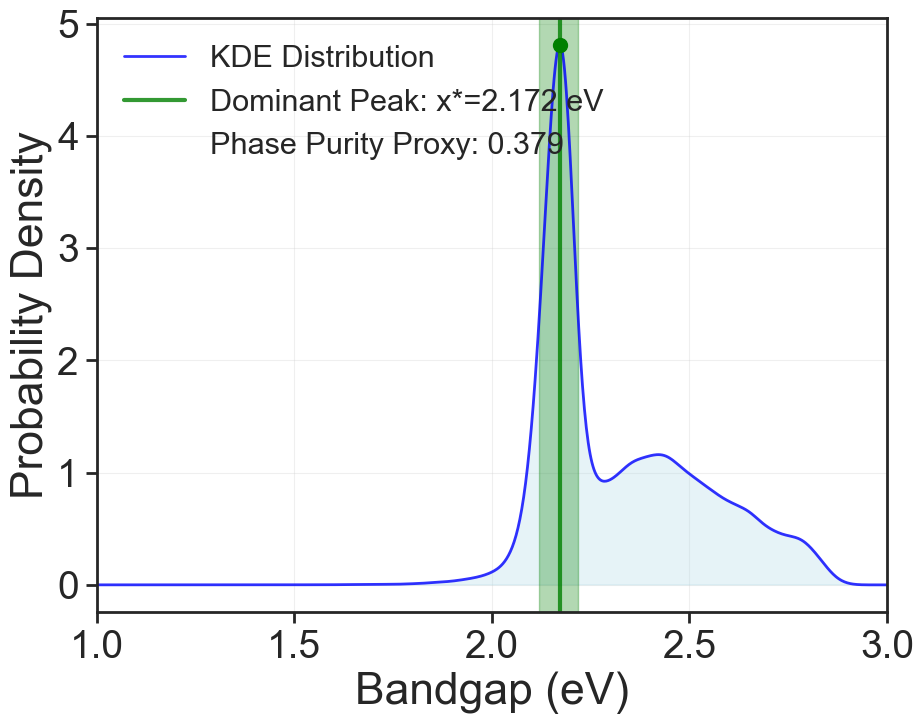

Phase purity score: 0.3793
Dominant peak x*: 2.172 eV
FWHM: 0.098 eV
Bandgaps found: 52528
Valid pixels: 30788/36606

Processing Film 30...
Pixels: 37226 total, 32978 valid, 4248 invalid (f_valid = 0.886)
Dominant peak found at x* = 2.167 eV with height = 3.178
FWHM = 0.212 eV, integration window: [2.120, 2.332] eV
Peak integration (within FWHM): 0.539
Phase purity score (FWHM-based): 0.5393


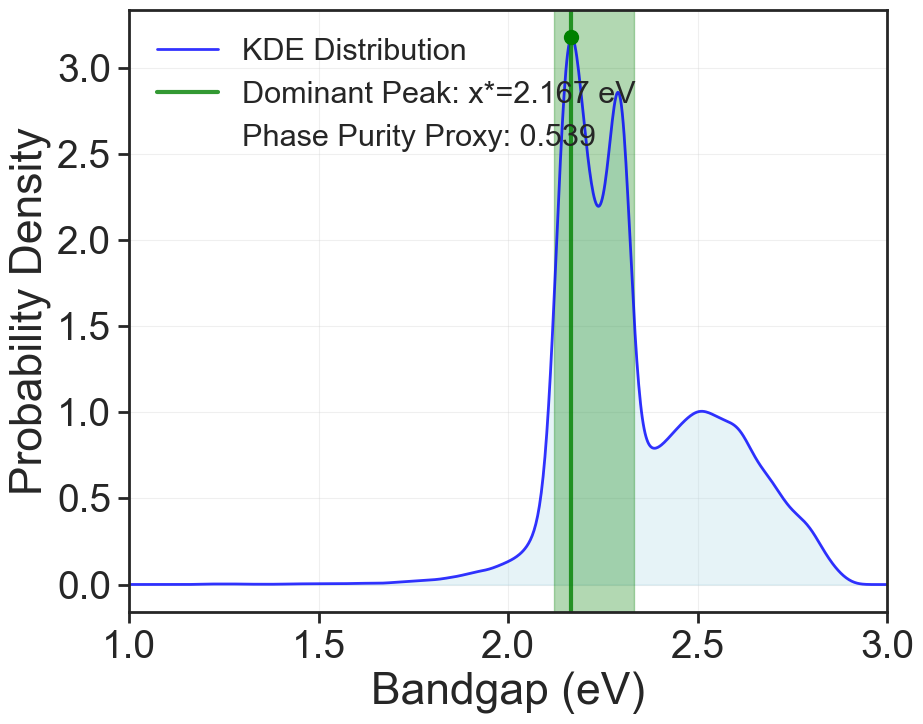

Phase purity score: 0.5393
Dominant peak x*: 2.167 eV
FWHM: 0.212 eV
Bandgaps found: 55080
Valid pixels: 32978/37226

Processing Film 31...
Pixels: 37459 total, 34246 valid, 3213 invalid (f_valid = 0.914)
Dominant peak found at x* = 2.258 eV with height = 3.932
FWHM = 0.147 eV, integration window: [2.178, 2.325] eV
Peak integration (within FWHM): 0.470
Phase purity score (FWHM-based): 0.4701


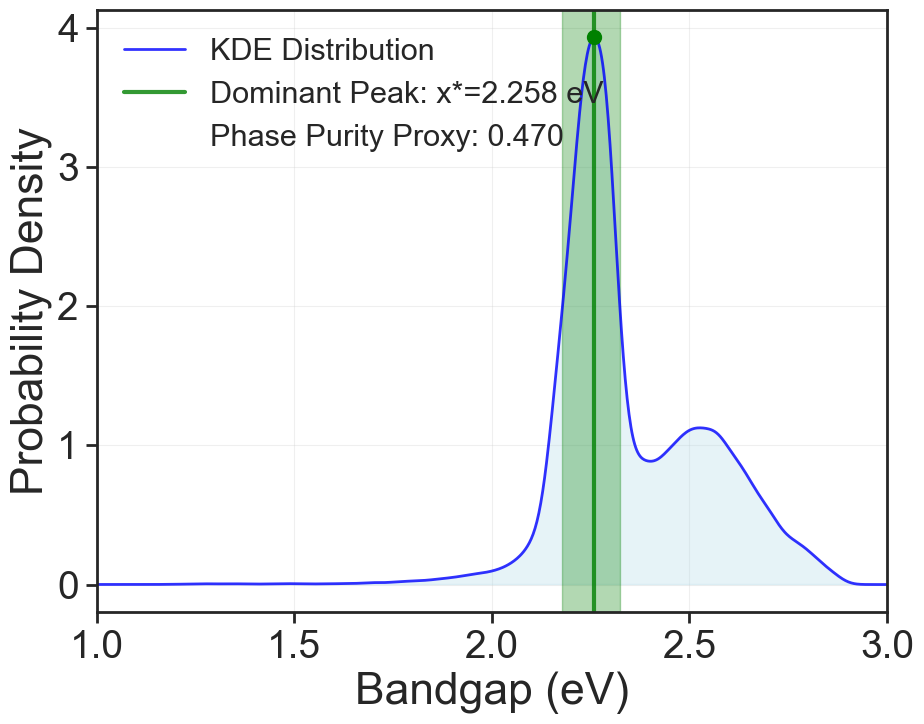

Phase purity score: 0.4701
Dominant peak x*: 2.258 eV
FWHM: 0.147 eV
Bandgaps found: 57476
Valid pixels: 34246/37459

Processing Film 32...
Pixels: 37124 total, 34585 valid, 2539 invalid (f_valid = 0.932)
Dominant peak found at x* = 2.277 eV with height = 3.530
FWHM = 0.202 eV, integration window: [2.113, 2.315] eV
Peak integration (within FWHM): 0.566
Phase purity score (FWHM-based): 0.5660


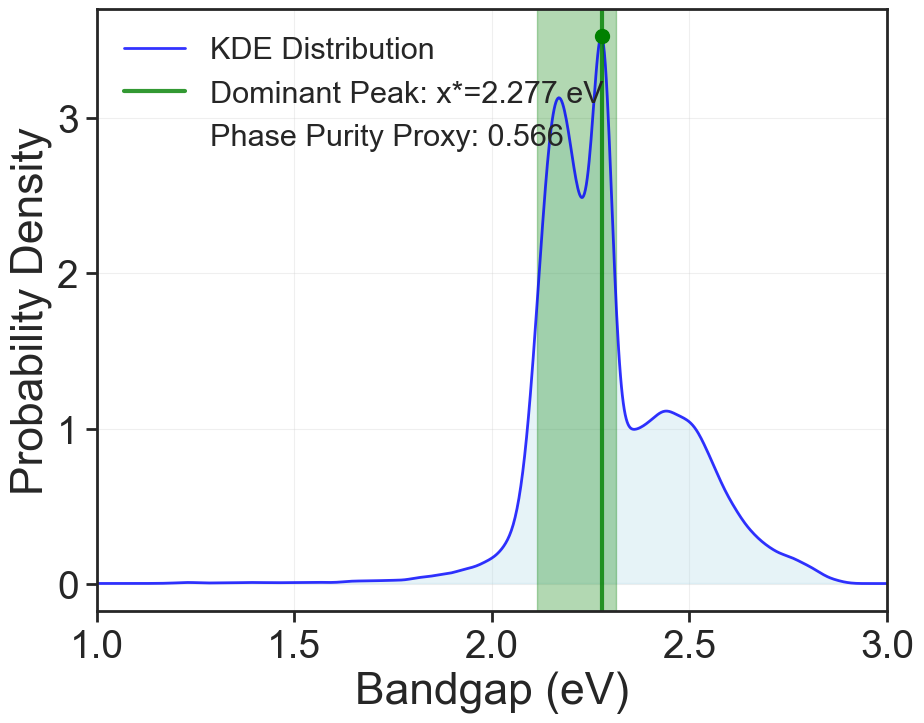

Phase purity score: 0.5660
Dominant peak x*: 2.277 eV
FWHM: 0.202 eV
Bandgaps found: 58105
Valid pixels: 34585/37124

Processing Film 33...
Pixels: 37165 total, 33298 valid, 3867 invalid (f_valid = 0.896)
Dominant peak found at x* = 2.153 eV with height = 6.834
FWHM = 0.081 eV, integration window: [2.112, 2.193] eV
Peak integration (within FWHM): 0.440
Phase purity score (FWHM-based): 0.4400


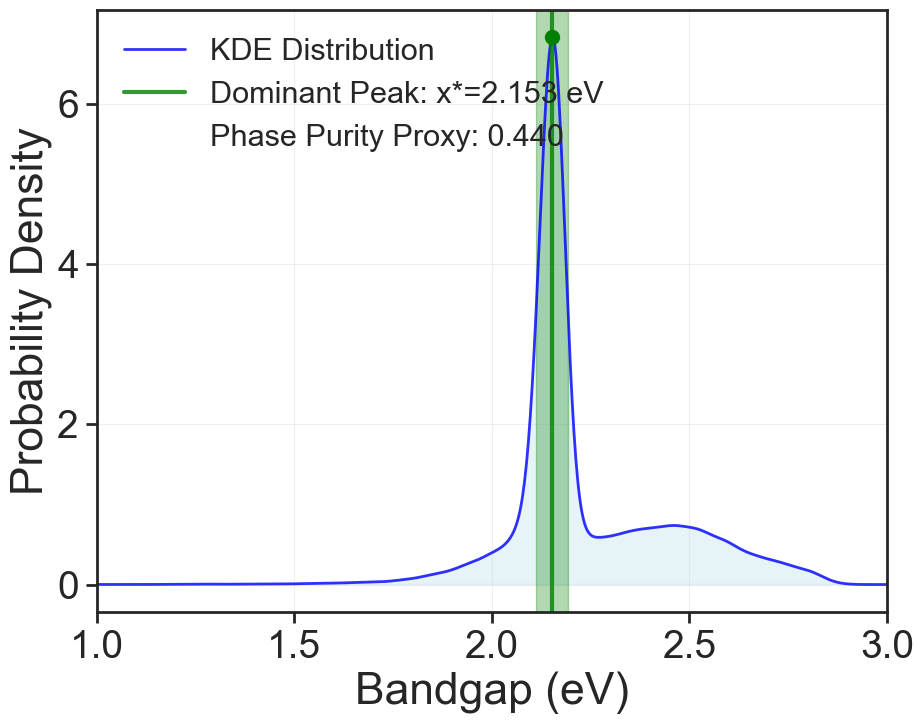

Phase purity score: 0.4400
Dominant peak x*: 2.153 eV
FWHM: 0.081 eV
Bandgaps found: 55350
Valid pixels: 33298/37165

Processing Film 34...
Pixels: 37152 total, 31331 valid, 5821 invalid (f_valid = 0.843)
Dominant peak found at x* = 2.162 eV with height = 6.314
FWHM = 0.084 eV, integration window: [2.120, 2.204] eV
Peak integration (within FWHM): 0.428
Phase purity score (FWHM-based): 0.4282


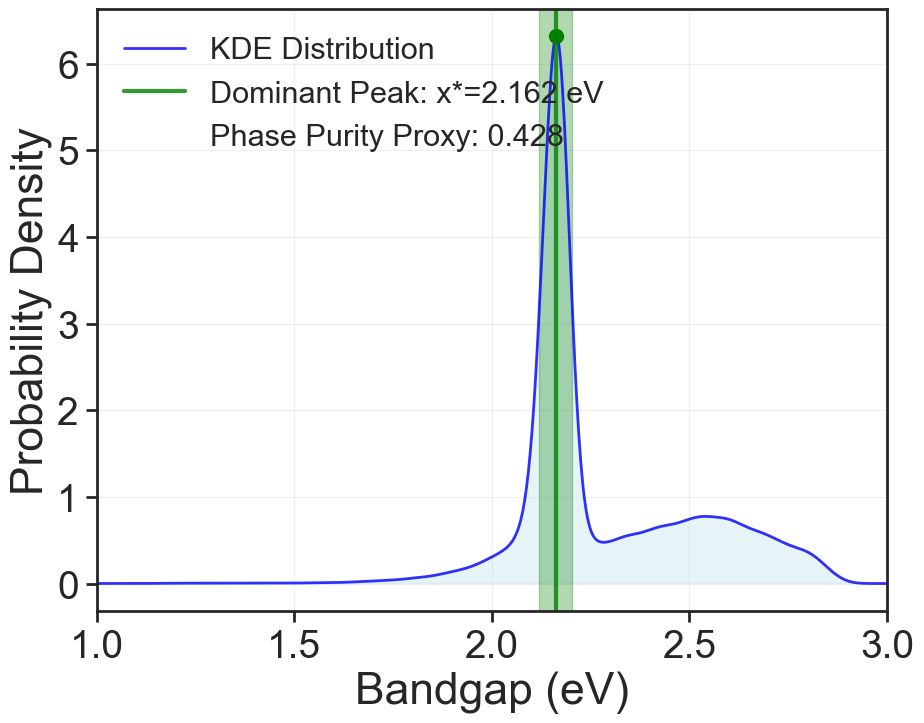

Phase purity score: 0.4282
Dominant peak x*: 2.162 eV
FWHM: 0.084 eV
Bandgaps found: 51868
Valid pixels: 31331/37152

Processing Film 35...
Pixels: 37129 total, 34263 valid, 2866 invalid (f_valid = 0.923)
Dominant peak found at x* = 2.148 eV with height = 7.174
FWHM = 0.079 eV, integration window: [2.107, 2.186] eV
Peak integration (within FWHM): 0.448
Phase purity score (FWHM-based): 0.4484


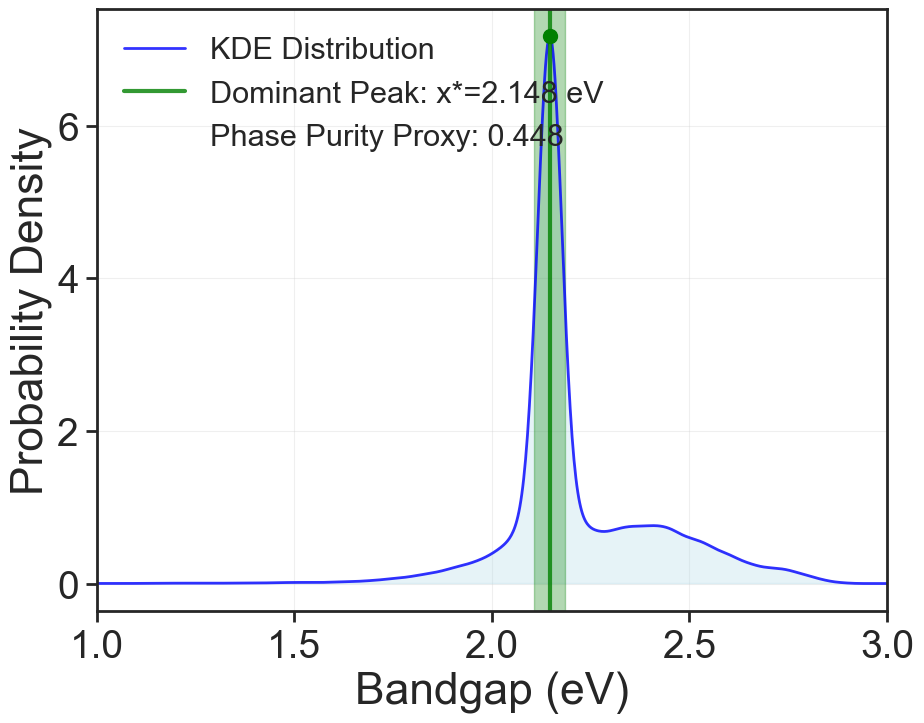

Phase purity score: 0.4484
Dominant peak x*: 2.148 eV
FWHM: 0.079 eV
Bandgaps found: 55328
Valid pixels: 34263/37129

Processing Film 36...
Exception: [Errno 2] No such file or directory: '/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/film_36_bandgaps.csv'

Processing Film 37...
Exception: [Errno 2] No such file or directory: '/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/film_37_bandgaps.csv'

Processing Film 38...
Exception: [Errno 2] No such file or directory: '/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/film_38_bandgaps.csv'

Processing Film 39...
Exception: [Errno 2] No such file or directory: '/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/film_39_bandgaps.csv'

Processing Film 40...
Exception: [Errno 2] No such file or

In [29]:
# datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/MAFAPbI3_Test/'
# savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/Code/phase_purity_testset/MAFAPbI3_Test/phase_purity_simplified_results/'
datapath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/'
savepath = f'/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2024-2026 TRI/04_Data/HSI/Rb3BiI6/LLM_BO_Round0/phase_purity_simplified_results/'

# Analysis parameters
analysis_params = {
    'ev_min': 1.0,          # Minimum energy for bandgap analysis
    'ev_max': 3.0,           # Maximum energy for bandgap analysis
}

# Initialize results list
phase_purity_list = []

# Process each film (following your format)
for film_idx in range(0, 43):
    print(f"\nProcessing Film {film_idx}...")
    # if film_idx == 24 or film_idx == 25 or film_idx == 26:
    #     print(f"Skipping Film {film_idx} due to synthesis failure.")
    #     phase_purity_list.append(0.00)
    #     continue

    try:
        df = pd.read_csv(f"{datapath}film_{film_idx}_bandgaps.csv", header=None)
        # skip first row
        data = df.iloc[1:]
        # convert to numeric
        data = data.apply(pd.to_numeric, errors='coerce')
        # convert each row → list of valid bandgaps
        bandgaps = [
            [bg for bg in row if bg > 0 and np.isfinite(bg)]
            for row in data.values
        ]
        phase_purity_results = calculate_phase_purity_score(
            bandgaps,
            **analysis_params,
            return_debug=True,
            save_figures=True,
            
        )

        if 'error' in phase_purity_results:
            print(f"Error: {phase_purity_results['error']}")
            phase_purity_score = np.nan
        else:
            phase_purity_score = phase_purity_results['phase_purity_score']
            print(f"Phase purity score: {phase_purity_score:.4f}")
            print(f"Dominant peak x*: {phase_purity_results['dominant_peak']:.3f} eV")
            print(f"FWHM: {phase_purity_results['peak_fwhm']:.3f} eV")
            print(f"Bandgaps found: {phase_purity_results['n_bandgaps']}")
            print(f"Valid pixels: {phase_purity_results['n_valid_pixels']}/{phase_purity_results['n_total_pixels']}")
        phase_purity_list.append(phase_purity_score)
        
    except Exception as e:
        print(f"Exception: {str(e)}")
        phase_purity_list.append(np.nan)

# Create individual results DataFrame
df_phase_purity = pd.DataFrame({
    "film_id": range(len(phase_purity_list)),
    "phase_purity": phase_purity_list
})

# Display individual results
print(df_phase_purity)

# Save individual results
df_phase_purity.to_csv(f"{savepath}/phase_purity_bandgap_simplified.csv", index=False)

# phase_purity_avg = []
# phase_purity_std = []
# group_size = 3

# for i in range(0, len(phase_purity_list), group_size):
#     group = phase_purity_list[i:i + group_size]
    
#     # Filter out NaN values for group statistics
#     valid_group = [x for x in group if not np.isnan(x)]
    
#     if len(valid_group) > 0:
#         purity_avg = np.mean(valid_group)
#         purity_std = np.std(valid_group, ddof=1) if len(valid_group) > 1 else 0.0
#     else:
#         purity_avg = np.nan
#         purity_std = np.nan
    
#     phase_purity_avg.append(purity_avg)
#     phase_purity_std.append(purity_std)

#     print(f'Group {i//group_size}: Avg = {purity_avg:.3f}, Std = {purity_std:.3f}')

# # Create group summary DataFrame
# df_phase_purity_summary = pd.DataFrame({
#     "group_id": range(len(phase_purity_avg)),
#     "phase_purity_avg": phase_purity_avg,
#     "phase_purity_std": phase_purity_std
# })
# print(df_phase_purity_summary)

# # Save group summary
# df_phase_purity_summary.to_csv(f"{savepath}/phase_purity_summary_bandgap.csv", index=False)